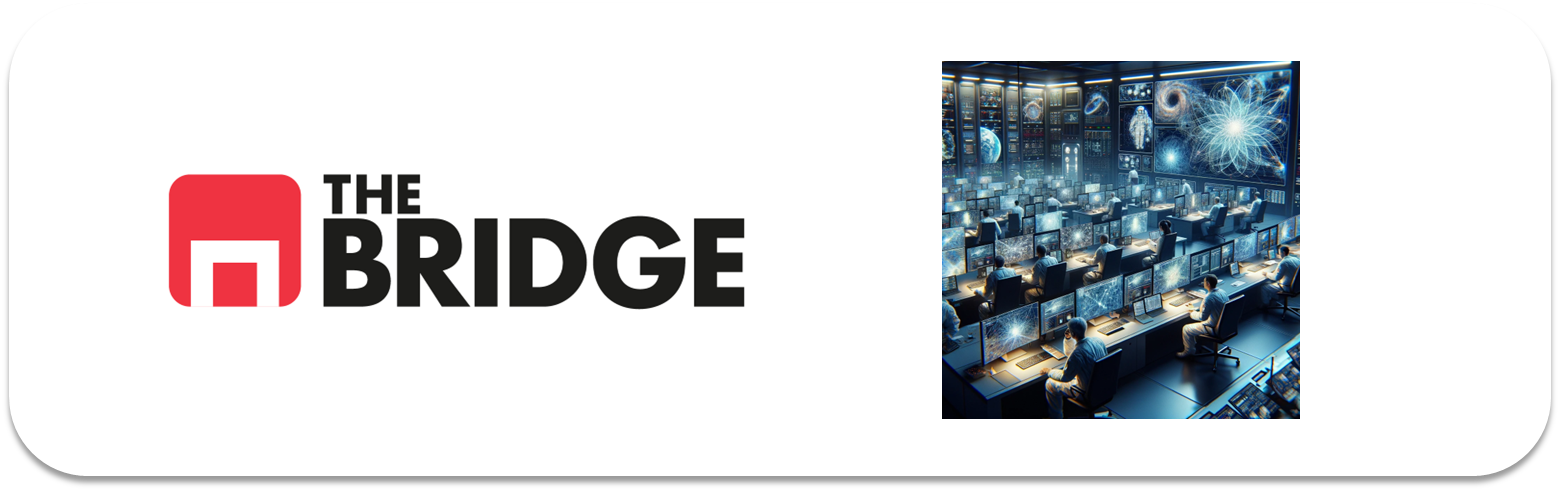

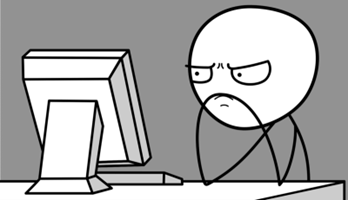

Para ejercitarte y afianzar lo aprendido sobre **Redes Convolucionales**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

## El problema de "Negocio"
Para este ejercicio vas a crear un clasificador automático de paisajes. Los datos los encontrarás en https://www.kaggle.com/datasets/puneet6060/intel-image-classification?select=seg_test como `seg_train.zip` y `seg_test.zip` (o bien en el botón de download).  

NOTA: Son archivos bastante grandes (386MB en total). Por supuesto, no es necesario que tengas que mantenerlos en tu ordenador una vez realizado el ejercicio, bórralos si es el caso.




### Ejercicio 1

Cargar las imágenes. Mira cómo están almacenados los datos. Tendrás que recorrer las carpetas, cargar las imágenes en memoria y etiquetarlas con los nombres de las carpetas. Realiza un reshape de cada imagen (comienza el ejercicio con 32x32, para ir más rápido en las ejecuciones). Para ello:

1. Descarga las imagenes del repositorio de Kaggle en el directorio que vayas a emplear para el ejercicio.
2. Descomprime los datos (son ficheros de imágenes) de forma que tengas dos subdirectorios seg_train y seg_test en el que estén ya colgando directamente los directorios de cada clase de paisajes. Si descargaste seg_pred, puedes eliminarlo.
3. Crea unas variables como las siguientes (ajustándolas a tu caso/rutas particulares):

```python
ROOT_PATH = './data/'
TRAIN_PATH = ROOT_PATH + "seg_train/"
TEST_PATH = ROOT_PATH + "seg_test/"
```
4. Utiliza la siguiente función para crear los X_train, y_train y X_test e y_test:

```python
def read_data(directorio, reshape_dim = (32,32)):
    X = []
    y = []
    for folder in os.listdir(directorio):
        if os.path.isdir('/'.join([directorio, folder])):
            for file in os.listdir('/'.join([directorio, folder])):

                image = imread('/'.join([directorio, folder, file]))
                image = cv2.resize(image, reshape_dim) # Redimensionamos las imágenes a 32x32

                X.append(image)
                y.append(folder)

    return np.array(X),np.array(y)
```


*Pues copiamos lo que nos dicen y lo aplicamos a los dos directorios para tener las X y las y*

In [ ]:
import os
import numpy as np
import cv2
from imageio import imread

In [36]:
import os

# Ruta base: la carpeta donde está tu notebook
BASE_PATH = os.getcwd()

# Carpeta data dentro del notebook
ROOT_PATH = os.path.join(BASE_PATH, 'data')

# Rutas de train y test
TRAIN_PATH = os.path.join(ROOT_PATH, 'seg_train')
TEST_PATH  = os.path.join(ROOT_PATH, 'seg_test')

# Si dentro de seg_train hay otra carpeta seg_train, la usamos
if 'seg_train' in os.listdir(TRAIN_PATH):
    TRAIN_PATH = os.path.join(TRAIN_PATH, 'seg_train')

# Si dentro de seg_test hay otra carpeta seg_test, la usamos
if 'seg_test' in os.listdir(TEST_PATH):
    TEST_PATH = os.path.join(TEST_PATH, 'seg_test')

print("ROOT_PATH:", ROOT_PATH)
print("TRAIN_PATH:", TRAIN_PATH)
print("TEST_PATH:", TEST_PATH)
print("Contenido de TRAIN_PATH:", os.listdir(TRAIN_PATH))
print("Contenido de TEST_PATH:", os.listdir(TEST_PATH))


ROOT_PATH: c:\Users\Usuario\Documents\GitHub\DS-Online-Marta-Harana\05_Deep_Learning\Sprint_16\Unidad_01_CNN_Redes_Convolucionales\02_Ejercicios_Workout\data
TRAIN_PATH: c:\Users\Usuario\Documents\GitHub\DS-Online-Marta-Harana\05_Deep_Learning\Sprint_16\Unidad_01_CNN_Redes_Convolucionales\02_Ejercicios_Workout\data\seg_train\seg_train
TEST_PATH: c:\Users\Usuario\Documents\GitHub\DS-Online-Marta-Harana\05_Deep_Learning\Sprint_16\Unidad_01_CNN_Redes_Convolucionales\02_Ejercicios_Workout\data\seg_test\seg_test
Contenido de TRAIN_PATH: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Contenido de TEST_PATH: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [37]:
def read_data(directorio, reshape_dim = (32,32)):
    X = []
    y = []
    for folder in os.listdir(directorio):
        if os.path.isdir('/'.join([directorio, folder])):
            for file in os.listdir('/'.join([directorio, folder])):

                image = imread('/'.join([directorio, folder, file]))
                image = cv2.resize(image, reshape_dim) # Redimensionamos las imágenes a 32x32

                X.append(image)
                y.append(folder)

    return np.array(X),np.array(y)


In [38]:
X_train, y_train = read_data(TRAIN_PATH, reshape_dim=(32,32))
X_test, y_test = read_data(TEST_PATH, reshape_dim=(32,32))


C:\Users\Usuario\AppData\Local\Temp\ipykernel_26500\811293433.py:8: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imread('/'.join([directorio, folder, file]))


### Ejercicio 2

Haz la visualización del dataset: comprueba cuantos datos tienes, que forma, investiga las imágenes, comprueba con algunas muestras que has cargado bien los datos.


In [39]:
print("Número de imágenes en TRAIN:", len(X_train))
print("Número de imágenes en TEST:", len(X_test))


Número de imágenes en TRAIN: 14034
Número de imágenes en TEST: 3000


In [40]:
print("Forma de X_train:", X_train.shape)
print("Forma de X_test:", X_test.shape)

Forma de X_train: (14034, 32, 32, 3)
Forma de X_test: (3000, 32, 32, 3)


In [41]:
print("Clases en y_train:", np.unique(y_train))
print("Clases en y_test:", np.unique(y_test))

Clases en y_train: ['buildings' 'forest' 'glacier' 'mountain' 'sea' 'street']
Clases en y_test: ['buildings' 'forest' 'glacier' 'mountain' 'sea' 'street']


In [42]:
from collections import Counter

print("Distribución en TRAIN:")
print(Counter(y_train))

print("\nDistribución en TEST:")
print(Counter(y_test))


Distribución en TRAIN:
Counter({np.str_('mountain'): 2512, np.str_('glacier'): 2404, np.str_('street'): 2382, np.str_('sea'): 2274, np.str_('forest'): 2271, np.str_('buildings'): 2191})

Distribución en TEST:
Counter({np.str_('glacier'): 553, np.str_('mountain'): 525, np.str_('sea'): 510, np.str_('street'): 501, np.str_('forest'): 474, np.str_('buildings'): 437})


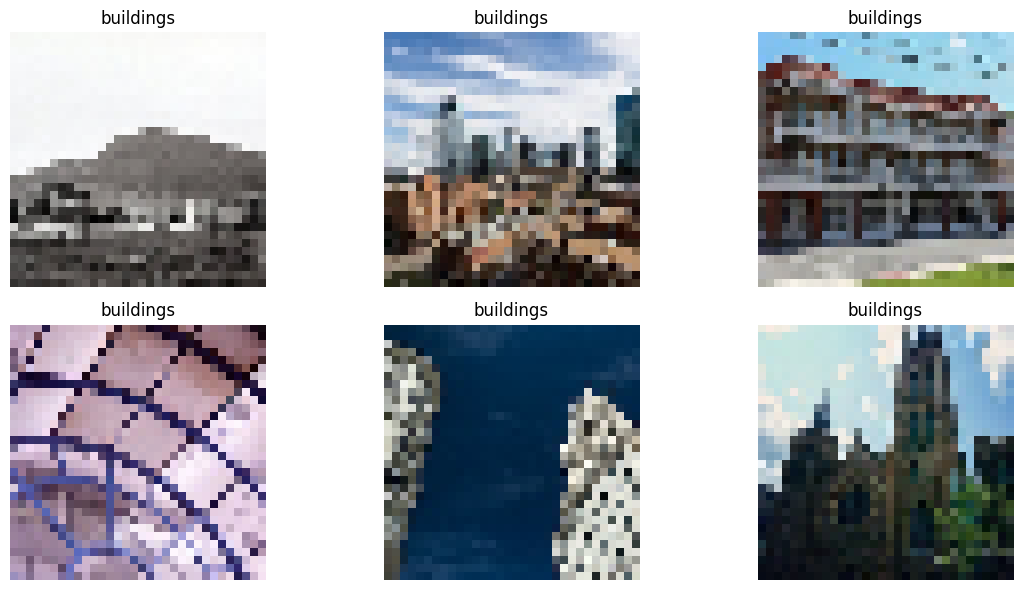

In [43]:
# Visualizar algunas imágenes para comprobar que se han cargado bien
import matplotlib.pyplot as plt

def show_samples(X, y, n=6):
    plt.figure(figsize=(12, 6))
    for i in range(n):
        plt.subplot(2, 3, i+1)
        plt.imshow(X[i])
        plt.title(y[i])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(X_train, y_train)


In [ ]:
# Comprobar los valores de los píxeles
print("Valor mínimo:", X_train.min())
print("Valor máximo:", X_train.max())


Valor mínimo: 0
Valor máximo: 255


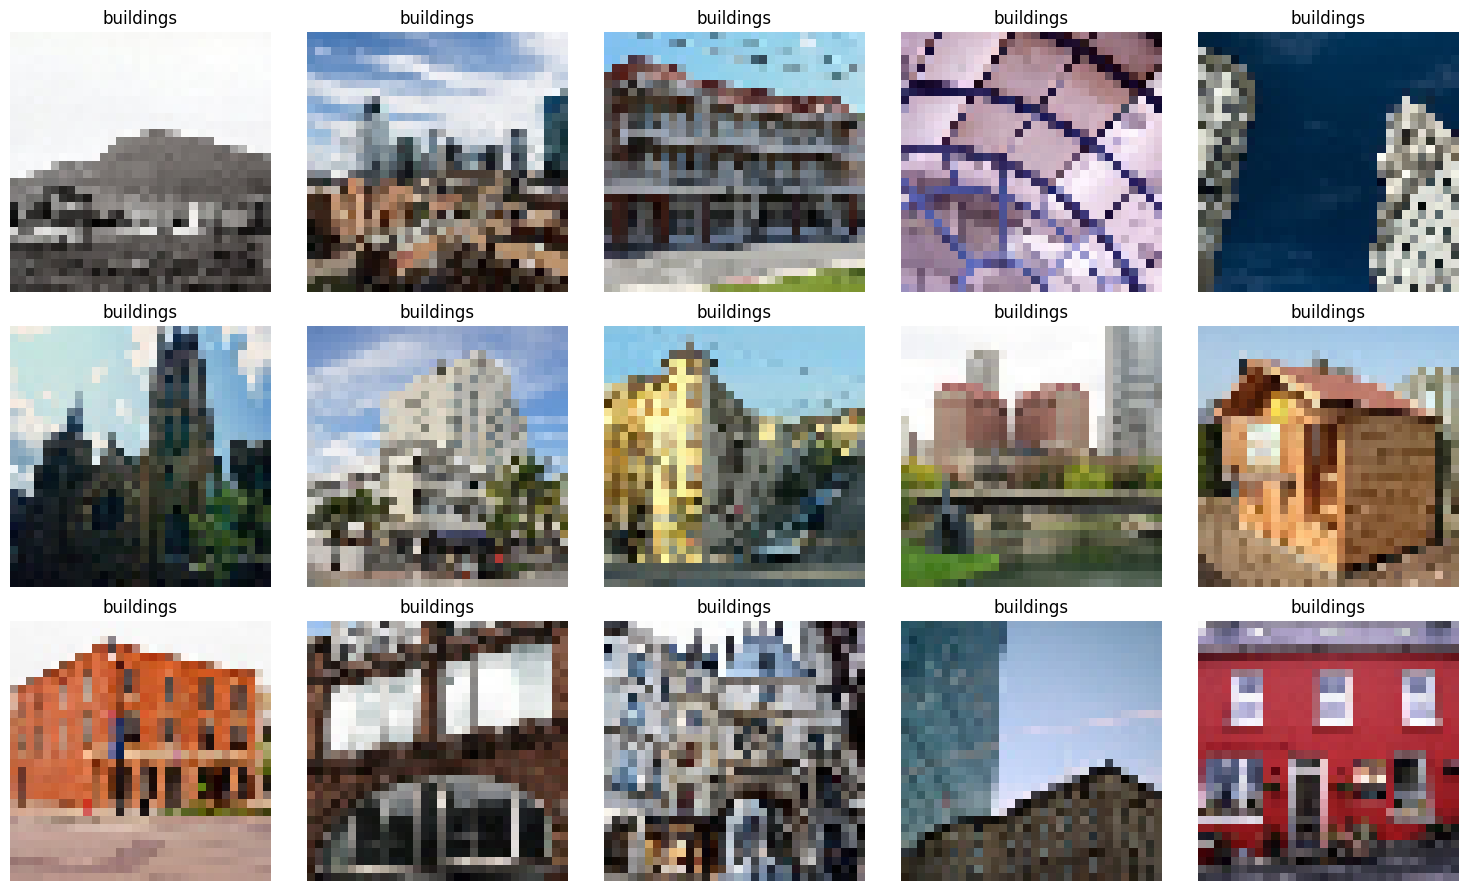

In [45]:
def plot_grid(X, y, rows=3, cols=5):
    plt.figure(figsize=(15, 9))
    for i in range(rows * cols):
        plt.subplot(rows, cols, i+1)
        plt.imshow(X[i])
        plt.title(y[i])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

plot_grid(X_train, y_train)


### Ejercicio 3

Ahora haz un pequeño miniEda y normaliza las features



In [ ]:
# Dimensiones del dataset
print("X_train:", X_train.shape)
print("y_train:", len(y_train))
print("X_test:", X_test.shape)
print("y_test:", len(y_test))

X_train: (14034, 32, 32, 3)
y_train: 14034
X_test: (3000, 32, 32, 3)
y_test: 3000


In [ ]:
# Normalizar las features
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm  = X_test.astype('float32') / 255.0

In [47]:
# Comprobación de la normalización
print("Nuevo mínimo:", X_train_norm.min())
print("Nuevo máximo:", X_train_norm.max())
print("Tipo:", X_train_norm.dtype)


Nuevo mínimo: 0.0
Nuevo máximo: 1.0
Tipo: float32


### Ejercicio 4

Diseña la arquitectura de la red. Recuerda que es un algiritmo de clasificación. Ojo con las dimensiones de la entrada. Como guía, copia o parte de la arquitectura del workout (un par de capas Conv2D + MaxPooling2D con activación relu y después la fully connected layer)


In [49]:
from tensorflow.keras import layers, models

model = models.Sequential()

# --- Bloque 1 ---
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

# --- Bloque 2 ---
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# --- Bloque 3 ---
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# --- Fully Connected ---
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.3))

# --- Capa de salida ---
model.add(layers.Dense(6, activation='softmax'))  # 6 clases

# --- Compilación ---
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


c:\Users\Usuario\Documents\GitHub\DS-Online-Marta-Harana\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159,686 (623.77 KB)

 Trainable params: 159,686 (623.77 KB)

 Non-trainable params: 0 (0.00 B)

### Ejercicio 5

Escoge el resto de hiperparámetros (optimizador, learning_rate, función de pérdida, métrica,...) y compila el modelo. Muestra un resumen del mismo

In [ ]:
from tensorflow.keras import optimizers

# Elegimos el optimizador con su learning rate
optimizer = optimizers.Adam(learning_rate=0.001)

# Compilamos el modelo
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [51]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159,686 (623.77 KB)

 Trainable params: 159,686 (623.77 KB)

 Non-trainable params: 0 (0.00 B)

### Ejercicio 6

Entrena el modelo reservando un 20% de los datos del entrenamiento para validar y con los callbacks que creas necesarios. NOTA: Ojo, tendrás que preparar un poco los X,y antes.

In [52]:
import numpy as np

# Obtener las clases únicas
classes = np.unique(y_train)

# Crear un diccionario: clase → número
class_to_int = {cls: i for i, cls in enumerate(classes)}

# Convertir etiquetas
y_train_int = np.array([class_to_int[label] for label in y_train])
y_test_int  = np.array([class_to_int[label] for label in y_test])


In [63]:
from sklearn.utils import shuffle

X_train_norm, y_train_int = shuffle(X_train_norm, y_train_int, random_state=42)


In [64]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.20
)

datagen.fit(X_train_norm)


In [65]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6
)


In [66]:
batch_size = 32

history = model.fit(
    datagen.flow(X_train_norm, y_train_int, batch_size=batch_size, subset='training'),
    validation_data=datagen.flow(X_train_norm, y_train_int, batch_size=batch_size, subset='validation'),
    epochs=100,
    callbacks=[early_stop, checkpoint, reduce_lr]
)


Epoch 1/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5941 - loss: 1.2970 - val_accuracy: 0.6568 - val_loss: 0.9763 - learning_rate: 6.2500e-05
Epoch 2/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.6501 - loss: 0.9446 - val_accuracy: 0.6771 - val_loss: 0.8838 - learning_rate: 6.2500e-05
Epoch 3/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.6706 - loss: 0.8898 - val_accuracy: 0.6782 - val_loss: 0.8676 - learning_rate: 6.2500e-05
Epoch 4/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.6750 - loss: 0.8716 - val_accuracy: 0.6832 - val_loss: 0.8430 - learning_rate: 6.2500e-05
Epoch 5/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.6792 - loss: 0.8597 - val_accuracy: 0.6842 - val_loss: 0.8273 - learning_rate: 6.2500e-05
Epoch 6/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.6889 - loss: 0.8450 - val_accuracy: 0.6910 - val_loss: 0.8217 - learning_rate: 6.2500e-05
Epoch 7/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/ste

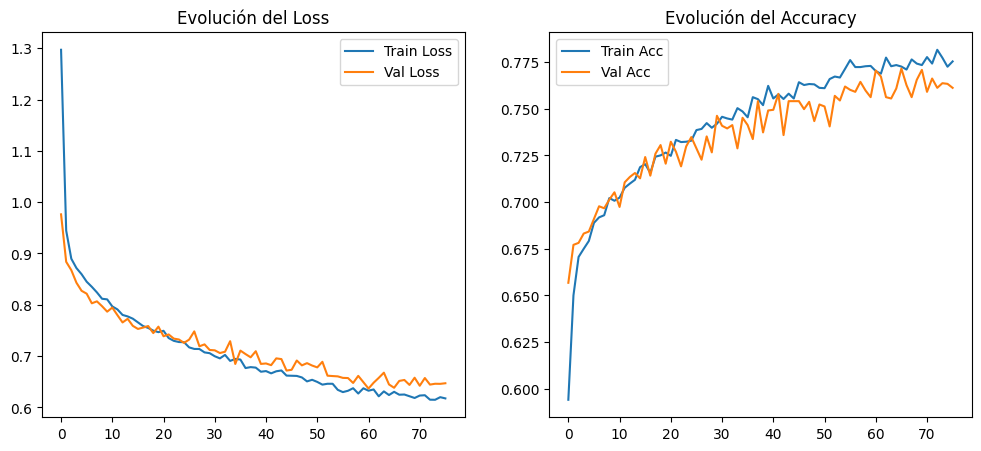

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Evolución del Loss')

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Evolución del Accuracy')

plt.show()



### Ejercicio 7

Representa el objeto history y comenta la evolución de tu entrenamiento.



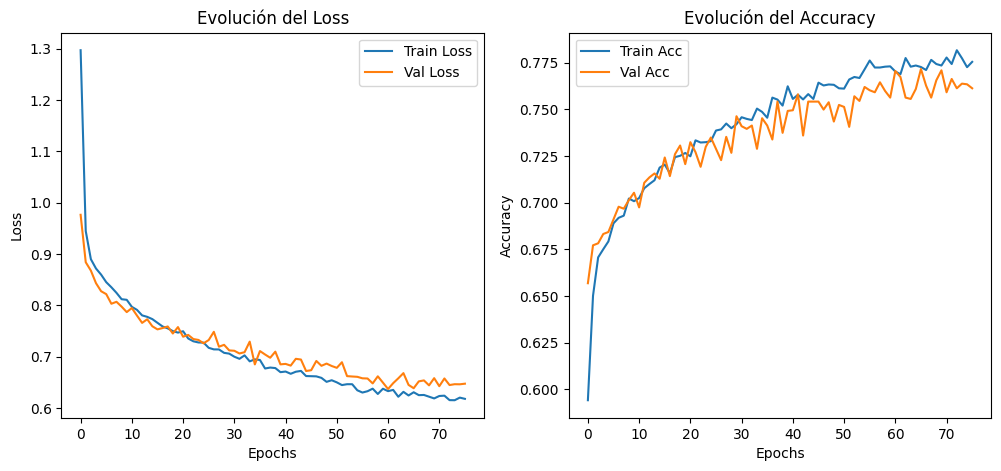

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# --- Evolución del Loss ---
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Evolución del Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# --- Evolución del Accuracy ---
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Evolución del Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()



### Ejercicio 8

Evalua el modelo con los datos de test, además muestra el report de clasificación y la matriz de confusión.

In [69]:
test_loss, test_acc = model.evaluate(X_test_norm, y_test_int, verbose=0)

print("🔹 Loss en test:", test_loss)
print("🔹 Accuracy en test:", test_acc)


🔹 Loss en test: 0.6182239055633545
🔹 Accuracy en test: 0.7763333320617676


In [70]:
y_pred_probs = model.predict(X_test_norm)
y_pred = y_pred_probs.argmax(axis=1)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [71]:
from sklearn.metrics import classification_report

print(classification_report(y_test_int, y_pred, target_names=classes))


              precision    recall  f1-score   support

   buildings       0.68      0.72      0.70       437
      forest       0.87      0.92      0.89       474
     glacier       0.76      0.75      0.75       553
    mountain       0.79      0.76      0.77       525
         sea       0.86      0.68      0.76       510
      street       0.72      0.84      0.78       501

    accuracy                           0.78      3000
   macro avg       0.78      0.78      0.78      3000
weighted avg       0.78      0.78      0.78      3000




### Ejercicio 9 

Representa algunos de los paisajes donde el modelo comete errores y muestra la confianza que tenía en ellos.

In [72]:
y_pred_probs = model.predict(X_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [73]:
errores_idx = np.where(y_pred != y_test_int)[0]
print("Número de errores:", len(errores_idx))

Número de errores: 671


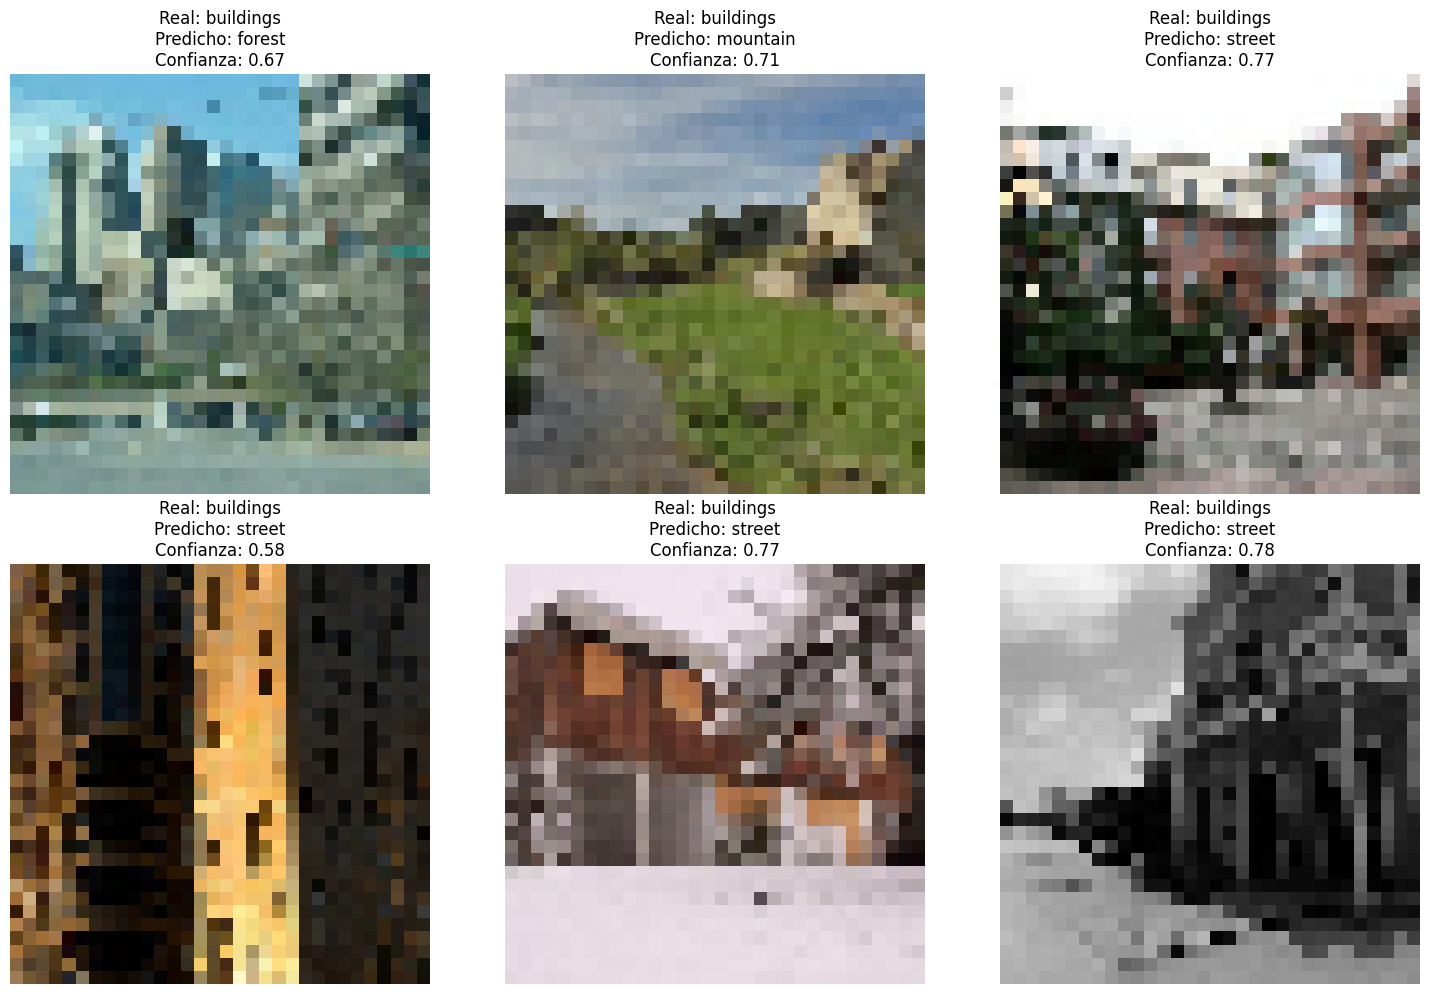

In [74]:
import matplotlib.pyplot as plt

def mostrar_errores(X, y_true, y_pred, probs, classes, n=6):
    plt.figure(figsize=(15, 10))
    
    for i, idx in enumerate(errores_idx[:n]):
        plt.subplot(2, 3, i+1)
        plt.imshow(X[idx])
        plt.axis("off")
        
        etiqueta_real = classes[y_true[idx]]
        etiqueta_pred = classes[y_pred[idx]]
        confianza = np.max(probs[idx])
        
        plt.title(f"Real: {etiqueta_real}\nPredicho: {etiqueta_pred}\nConfianza: {confianza:.2f}")
    
    plt.tight_layout()
    plt.show()

mostrar_errores(X_test, y_test_int, y_pred, y_pred_probs, classes)

### Ejercicio EXTRA: 

Aumenta la resolución y repite el ejercicio con la misma topología de red

In [75]:
import cv2
import numpy as np

NEW_SIZE = (128, 128)

def resize_batch(X, new_size):
    X_resized = np.zeros((len(X), new_size[0], new_size[1], 3), dtype=X.dtype)
    for i in range(len(X)):
        X_resized[i] = cv2.resize(X[i], new_size)
    return X_resized

X_train_hr = resize_batch(X_train, NEW_SIZE)
X_test_hr  = resize_batch(X_test, NEW_SIZE)

X_train_hr_norm = X_train_hr.astype("float32") / 255.0
X_test_hr_norm  = X_test_hr.astype("float32") / 255.0


In [76]:
from tensorflow.keras import layers, models, optimizers

model_hr = models.Sequential()

model_hr.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model_hr.add(layers.MaxPooling2D((2,2)))

model_hr.add(layers.Conv2D(64, (3,3), activation='relu'))
model_hr.add(layers.MaxPooling2D((2,2)))

model_hr.add(layers.Conv2D(128, (3,3), activation='relu'))
model_hr.add(layers.MaxPooling2D((2,2)))

model_hr.add(layers.Flatten())
model_hr.add(layers.Dense(128, activation='relu'))
model_hr.add(layers.Dropout(0.3))
model_hr.add(layers.Dense(6, activation='softmax'))

optimizer = optimizers.Adam(learning_rate=0.001)

model_hr.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_hr.summary()


c:\Users\Usuario\Documents\GitHub\DS-Online-Marta-Harana\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,414 (12.61 MB)

 Trainable params: 3,305,414 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [77]:
from sklearn.model_selection import train_test_split

X_train_split_hr, X_val_split_hr, y_train_split_hr, y_val_split_hr = train_test_split(
    X_train_hr_norm, y_train_int,
    test_size=0.20,
    stratify=y_train_int,
    random_state=42
)


In [78]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen_hr = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

datagen_hr.fit(X_train_split_hr)


In [79]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stop_hr = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

checkpoint_hr = ModelCheckpoint(
    'best_model_hr.keras',
    monitor='val_loss',
    save_best_only=True
)

reduce_lr_hr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6
)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# --- Evolución del Loss ---
plt.subplot(1,2,1)
plt.plot(history_hr.history['loss'], label='Train Loss')
plt.plot(history_hr.history['val_loss'], label='Val Loss')
plt.title('Evolución del Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# --- Evolución del Accuracy ---
plt.subplot(1,2,2)
plt.plot(history_hr.history['accuracy'], label='Train Acc')
plt.plot(history_hr.history['val_accuracy'], label='Val Acc')
plt.title('Evolución del Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()
